In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
#This code was used to produce #Chris_Validation Folder

In [3]:
def create_director_circ_w_parabola_both_ways(X, Y, Z,
                                              nx, ny, nz,
                                              Cx, Cy, Cz,
                                              R_f, f):
    """
    Director field in a single circular region of radius R_f centered at (Cx, Cy),
    with two parabolas opening in ±y that define a central 'vertical' region.
    Inside the parabola region: n = (0, 1, 0)
    Outside but inside the circle: n = radial from center in x-y.
    """
    nx = nx.astype(np.float64)
    ny = ny.astype(np.float64)
    nz = nz.astype(np.float64)
    
    distances_squared = (X - Cx)**2 + (Y - Cy)**2
    distances = np.sqrt(distances_squared)
    
    # circle mask based on filament radius R_f
    mask_circ = (distances <= R_f)
    # avoid division by zero
    distances = np.where(distances < 1e-6, 1e-6, distances)
    
    # two parabola conditions (for +/- y direction)
    parabola_mask1 = (4 * f * (Y - Cy + f)) >= (X - Cx)**2
    parabola_mask2 = (4 * f * (Cy - Y + f)) >= (X - Cx)**2
    
    # points inside the circle
    inside_parabola  = mask_circ & (parabola_mask1 | parabola_mask2)
    outside_parabola = mask_circ & ~(parabola_mask1 | parabola_mask2)
    
    # inside the parabola: vertical director
    nx[inside_parabola], ny[inside_parabola], nz[inside_parabola] = 0.0, 1.0, 0.0
    
    # outside but within circle: radial director in x-y
    x_val = (X[outside_parabola] - Cx) / distances[outside_parabola]
    y_val = (Y[outside_parabola] - Cy) / distances[outside_parabola]
    nx[outside_parabola], ny[outside_parabola], nz[outside_parabola] = x_val, y_val, 0.0
    
    return nx, ny, nz

# 2. Define the helical path and tangent functions (no q, use R_h explicitly)

def create_helical_path(center, R_h, P, num_points, num_turns, phase=0.0):
    """
    Helical centerline with an x-y phase offset that does NOT change z.
    """
    Cx, Cy, Cz = center

    theta = np.linspace(0.0, 2.0 * np.pi * num_turns, num_points)  # base parameter
    theta_xy = theta + phase                                       # phase only in x-y

    X = Cx + R_h * np.cos(theta_xy)
    Y = Cy + R_h * np.sin(theta_xy)
    Z = Cz + (P / (2.0 * np.pi)) * theta                            # z uses base theta

    return X, Y, Z, theta, theta_xy


def create_tangent_vectors(R_h, P, theta, theta_xy):
    """
    Unit tangent vectors for the phase-shifted helix (x-y uses theta_xy, z uses theta).
    """
    dz_dtheta = P / (2.0 * np.pi)

    dx_dtheta = -R_h * np.sin(theta_xy)
    dy_dtheta =  R_h * np.cos(theta_xy)
    dz_dtheta = dz_dtheta * np.ones_like(theta)

    norm = np.sqrt(dx_dtheta**2 + dy_dtheta**2 + dz_dtheta**2)
    norm[norm == 0] = 1.0

    return dx_dtheta / norm, dy_dtheta / norm, dz_dtheta / norm


# 3. Compute a local frame (u, v) perpendicular to a given tangent vector

def compute_local_frame(T):
    """
    Given a tangent vector T, return two orthonormal vectors (u, v)
    that span the plane perpendicular to T.
    """
    T = T / np.linalg.norm(T)
    if abs(T[2]) < 0.99:
        arbitrary = np.array([0.0, 0.0, 1.0])
    else:
        arbitrary = np.array([0.0, 1.0, 0.0])
    u = np.cross(arbitrary, T)
    u = u / np.linalg.norm(u)
    v = np.cross(T, u)
    return u, v

In [4]:
# ----------------------------
# Box size
# ----------------------------
Lx = Ly = Lz = 400

# ----------------------------
# Filament & helix parameters
# ----------------------------
R_f = 25.0              # filament radius R_F
Omega_C = 0.17          # overlap extent Ω_C
Rh_over_Rf = 1.04      # ratio R_H / R_F
R_h = Rh_over_Rf * R_f  # helix radius R_H
f = (Omega_C * R_f)/(2) #2f = tilda_R_o 
n_filaments = 2         # n = 2 filaments in the double helix

# ----------------------------
# Geometric relations
# ----------------------------
# d_s = 2 R_F (1 - Ω_C)
d_s = 2.0 * R_f * (1.0 - Omega_C)

# P = 4 R_F (1 - Ω_C) / sqrt[ 1 - ( 2 R_F (1 - Ω_C) / (π R_H) )^2 ]
sqrt_arg = 1.0 - (2.0 * R_f * (1.0 - Omega_C) / (np.pi * R_h))**2
if sqrt_arg <= 0:
    raise ValueError("Chosen (R_f, R_h, Omega_C) give no valid helix: sqrt argument ≤ 0.")

P = (4.0 * R_f * (1.0 - Omega_C)) / np.sqrt(sqrt_arg)

# Pitch angle θ_p:
# tan(θ_p) = 2π R_H / P
theta_p = np.arctan2(2.0 * np.pi * R_h, P)

# Check consistency with sin(θ_p) = n d_s / P
lhs = np.sin(theta_p)
rhs = n_filaments * d_s / P
print("Check sin(theta_p) ≈ n d_s / P:", lhs, rhs)
print("\n--- Helix parameters ---")
print(f"Filament radius R_f        = {R_f:.3f}")
print(f"Helix radius R_h           = {R_h:.3f}")
print(f"R_h / R_f                  = {R_h / R_f:.4f}")
print(f"Overlap Ω_C                = {Omega_C:.3f}")
print(f"Center-center spacing d_s  = {d_s:.3f}")
print(f"Pitch P                   = {P:.3f}")
print(f"Pitch angle θ_p (rad)      = {theta_p:.4f}")
print(f"Pitch angle θ_p (deg)      = {np.degrees(theta_p):.2f}")
print(f"Number of filaments n      = {n_filaments}")
print("------------------------")

# ----------------------------
# Helix length & discretization
# ----------------------------
helix_turns = 3
helix_length = P * helix_turns
num_points = 3000

# Print helix length diagnostics
print("\n--- Helix geometry ---")
print(f"Number of helix turns      = {helix_turns}")
print(f"Pitch P                   = {P:.3f}")
print(f"Total helix length (z)     = {helix_length:.3f}")
print("-----------------------\n")

z = np.linspace(0.0, helix_length, num_points)
phi = 2.0 * np.pi * z / P  # phase along helix

# ----------------------------
# Global centers for the double helix
# ----------------------------
global_center_1 = np.array([Lx/2.0, Ly/2.0, 1.4*R_f])
global_center_2 = np.array([Lx/2.0, Ly/2.0, 1.4*R_f])  # SAME z start

Check sin(theta_p) ≈ n d_s / P: 0.8613148675101684 0.8613148675101684

--- Helix parameters ---
Filament radius R_f        = 25.000
Helix radius R_h           = 26.000
R_h / R_f                  = 1.0400
Overlap Ω_C                = 0.170
Center-center spacing d_s  = 41.500
Pitch P                   = 96.364
Pitch angle θ_p (rad)      = 1.0379
Pitch angle θ_p (deg)      = 59.46
Number of filaments n      = 2
------------------------

--- Helix geometry ---
Number of helix turns      = 3
Pitch P                   = 96.364
Total helix length (z)     = 289.093
-----------------------



In [5]:
# Helical paths for the two filaments (use R_h and P explicitly)
# Helix 1: phase 0
X_path_1, Y_path_1, Z_path_1, theta_1, theta_xy_1 = create_helical_path(
    global_center_1, R_h, P, num_points, helix_turns, phase=0.0
)
tangent_x_1, tangent_y_1, tangent_z_1 = create_tangent_vectors(R_h, P, theta_1, theta_xy_1)

# Helix 2: phase pi (half-pitch offset)
X_path_2, Y_path_2, Z_path_2, theta_2, theta_xy_2 = create_helical_path(
    global_center_2, R_h, P, num_points, helix_turns, phase=np.pi
)
tangent_x_2, tangent_y_2, tangent_z_2 = create_tangent_vectors(R_h, P, theta_2, theta_xy_2)
# 4. For each point on the helical path, generate the tangent plane vector field patch

# 4. For each point on the helical path, generate the tangent-plane vector field patch
#    OPTION A: Helix path IS the filament centerline; one circle per helix.

# Set the local grid extent relative to filament radius R_f
plane_half_range = 2 * R_f          # or try 1.2 * R_f if you want tighter patches
plane_res = int(2 * plane_half_range) + 1

local_coords = np.linspace(-plane_half_range, plane_half_range, plane_res)
X_local, Y_local = np.meshgrid(local_coords, local_coords, indexing='ij')
Z_local = np.zeros_like(X_local)  # local z = 0

all_global_points = []
all_global_vectors = []

# -------- First filament (centerline = helix 1) --------
for i in range(num_points):
    origin = np.array([X_path_1[i], Y_path_1[i], Z_path_1[i]])
    tangent = np.array([tangent_x_1[i], tangent_y_1[i], tangent_z_1[i]])

    # Local frame in plane ⟂ tangent
    u, v = compute_local_frame(tangent)

    # Initialize local director field arrays
    nx_local = np.full_like(X_local, np.nan, dtype=float)
    ny_local = np.full_like(Y_local, np.nan, dtype=float)
    nz_local = np.full_like(Z_local, np.nan, dtype=float)

    # Single filament: circle of radius R_f centered at (0,0) in local coordinates
    center_local = (0.0, 0.0, 0.0)
    nx_local, ny_local, nz_local = create_director_circ_w_parabola_both_ways(
        X_local, Y_local, Z_local,
        nx_local, ny_local, nz_local,
        Cx=center_local[0], Cy=center_local[1], Cz=center_local[2],
        R_f=R_f, f=f
    )

    # Keep only non-NaN director values
    mask = (~np.isnan(nx_local)) & (~np.isnan(ny_local)) & (~np.isnan(nz_local))

    valid_X  = X_local[mask]
    valid_Y  = Y_local[mask]
    valid_nx = nx_local[mask]
    valid_ny = ny_local[mask]

    # Map local coordinates to global
    valid_global_points = origin + valid_X[:, None] * u + valid_Y[:, None] * v

    # Map local director (x,y) to global direction
    valid_global_vectors = valid_nx[:, None] * u + valid_ny[:, None] * v

    all_global_points.append(valid_global_points)
    all_global_vectors.append(valid_global_vectors)

# -------- Second filament (centerline = helix 2) --------
for i in range(num_points):
    origin = np.array([X_path_2[i], Y_path_2[i], Z_path_2[i]])
    tangent = np.array([tangent_x_2[i], tangent_y_2[i], tangent_z_2[i]])

    u, v = compute_local_frame(tangent)

    nx_local = np.full_like(X_local, np.nan, dtype=float)
    ny_local = np.full_like(Y_local, np.nan, dtype=float)
    nz_local = np.full_like(Z_local, np.nan, dtype=float)

    center_local = (0.0, 0.0, 0.0)
    nx_local, ny_local, nz_local = create_director_circ_w_parabola_both_ways(
        X_local, Y_local, Z_local,
        nx_local, ny_local, nz_local,
        Cx=center_local[0], Cy=center_local[1], Cz=center_local[2],
        R_f=R_f, f=f
    )

    mask = (~np.isnan(nx_local)) & (~np.isnan(ny_local)) & (~np.isnan(nz_local))

    valid_X  = X_local[mask]
    valid_Y  = Y_local[mask]
    valid_nx = nx_local[mask]
    valid_ny = ny_local[mask]

    valid_global_points = origin + valid_X[:, None] * u + valid_Y[:, None] * v
    valid_global_vectors = valid_nx[:, None] * u + valid_ny[:, None] * v

    all_global_points.append(valid_global_points)
    all_global_vectors.append(valid_global_vectors)

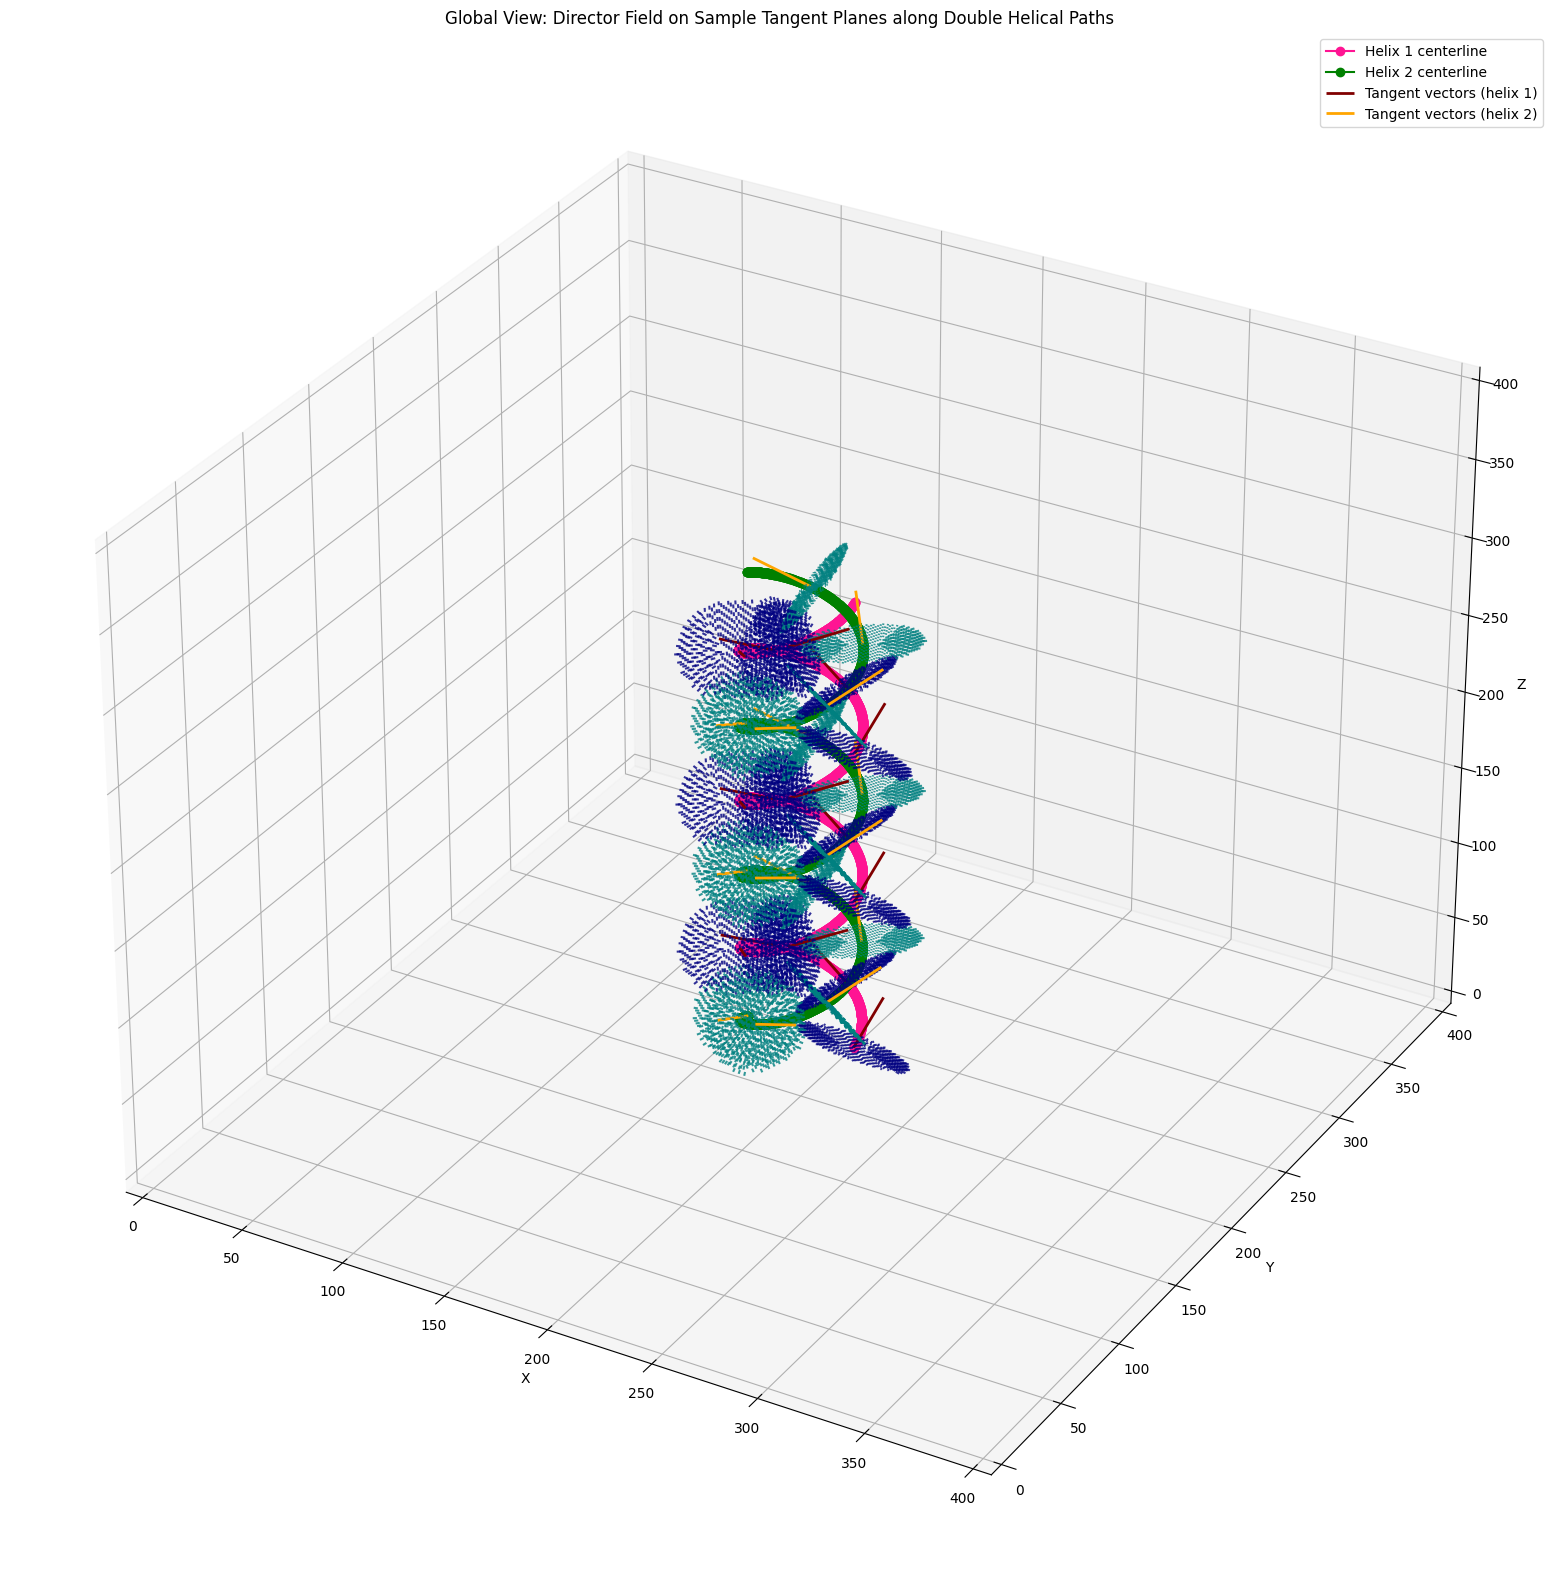

In [6]:
# ----------------------------
# 3D visualization of the two filaments
# ----------------------------
fig = plt.figure(figsize=(24, 20))
ax = fig.add_subplot(111, projection='3d')

# Plot every n_p-th tangent plane
n_p = 200        # how many planes you skip; smaller = denser
sample_rate = 4  # subsample vectors within each plane for clarity

#all_global_points / all_global_vectors:
#planes 0..num_points-1  : helix 1
#planes num_points..2*num_points-1 : helix 2
for i, (pts, vecs) in enumerate(zip(all_global_points, all_global_vectors)):
    if i % n_p == 0:
        # color code by which filament the patch belongs to
        color = 'navy' if i < num_points else 'teal'
        ax.quiver(
            pts[::sample_rate, 0],
            pts[::sample_rate, 1],
            pts[::sample_rate, 2],
            vecs[::sample_rate, 0],
            vecs[::sample_rate, 1],
            vecs[::sample_rate, 2],
            length=2.0,
            color=color,
            alpha=0.8,
            arrow_length_ratio=0
        )

## Plot both helical centerlines for context
ax.plot(
    X_path_1, Y_path_1, Z_path_1,
    'o-', color='deeppink', label='Helix 1 centerline'
)
ax.plot(
    X_path_2, Y_path_2, Z_path_2,
    'o-', color='green', label='Helix 2 centerline'
)

# Optionally: plot tangent vectors along each helical path
for j, (x, y, z, tx, ty, tz) in enumerate(
    zip(X_path_1, Y_path_1, Z_path_1,
        tangent_x_1, tangent_y_1, tangent_z_1)
):
    if j % n_p == 0:
        ax.quiver(
            x, y, z, tx, ty, tz,
            length=30,
            color='maroon',
            linewidths=2,
            arrow_length_ratio=0,
            label='Tangent vectors (helix 1)' if j == 0 else None
        )

for j, (x, y, z, tx, ty, tz) in enumerate(
    zip(X_path_2, Y_path_2, Z_path_2,
        tangent_x_2, tangent_y_2, tangent_z_2)
):
    if j % n_p == 0:
        ax.quiver(
            x, y, z, tx, ty, tz,
            length=30,
            color='orange',
            linewidths=2,
            arrow_length_ratio=0,
            label='Tangent vectors (helix 2)' if j == 0 else None
        )

ax.set_title("Global View: Director Field on Sample Tangent Planes along Double Helical Paths")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# Use your box size here; assuming Lx, Ly, Lz defined earlier
ax.set_xlim([0, Lx])
ax.set_ylim([0, Ly])
ax.set_zlim([0, Lz])

ax.legend()
plt.show()

In [7]:
all_points_flat = [pts.reshape(-1, 3) for pts in all_global_points]
all_vectors_flat = [vecs.reshape(-1, 3) for vecs in all_global_vectors]


final_points = np.concatenate(all_points_flat, axis=0)  # shape: (N, 3)
final_vectors = np.concatenate(all_vectors_flat, axis=0)

# Replace NaN values with 0
final_points = np.nan_to_num(final_points, nan=0)
final_vectors = np.nan_to_num(final_vectors, nan=0)

In [8]:
from scipy.spatial import cKDTree
import multiprocessing as mp
from scipy.interpolate import LinearNDInterpolator, griddata

# Define your maximum allowed distance (set as needed)
max_distance = 1  # for example; adjust to your desired threshold

# Build a KDTree from your scattered global points
tree = cKDTree(final_points)

def interpolate_single_slice(k):
    """Interpolate one z-slice using nearest neighbor with a distance threshold.
    
    Returns a (Lx, Ly, 3) float32 array.
    """
    X, Y = np.meshgrid(np.arange(Lx), np.arange(Ly), indexing='ij')
    Z = np.full_like(X, k)
    # Flatten the grid coordinates into (N, 3) points
    grid_coords = np.stack((X, Y, Z), axis=-1).reshape(-1, 3)
    
    # Query the nearest neighbor for each grid point
    distances, indices = tree.query(grid_coords, k=1)
    
    # Retrieve the corresponding vector values from final_vectors
    vectors = final_vectors[indices].copy()  # shape: (N, 3)
    
    # If the nearest neighbor is farther than max_distance, fill with 0
    vectors[distances > max_distance] = 0
    
    # Reshape the result back into grid form
    slice_director = vectors.reshape(X.shape[0], X.shape[1], 3).astype(np.float32)
    return slice_director

    print(k)

# Use multiprocessing to process each z-slice
with mp.get_context("fork").Pool(processes=32) as pool:
    director_slices = pool.map(interpolate_single_slice, range(Lz))

# Stack slices into a full 4D array: shape (Lx, Ly, Lz, 3)
director = np.stack(director_slices, axis=2)
print("Director field complete! Shape:", director.shape)

Director field complete! Shape: (400, 400, 400, 3)


In [9]:
#director[np.isnan(director)] = 0

nx = director[..., 0]
ny = director[..., 1]
nz = director[..., 2]

X, Y, Z = np.meshgrid(np.arange(Lx), np.arange(Ly), np.arange(Lz), indexing='ij')

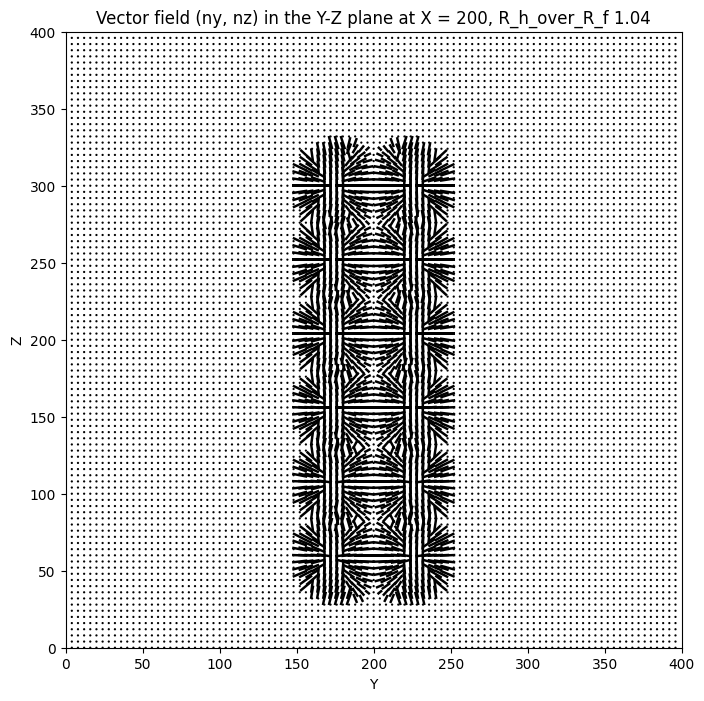

In [10]:
scale = 40
width = .004
headaxislength = 0
headlength = 0
headwidth = 1

k = 4

# Define thex-plane for display
x_display = int(Lx/2)  # You can set this to any value between 0 and Lx-1

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 8))

# Create a quiver plot for nx, nz in the X-Z plane at the specified X value
ax.quiver(Y[x_display, ::k, ::k], Z[x_display, ::k, ::k], ny[x_display, ::k, ::k], nz[x_display, ::k, ::k],
          pivot='middle', scale=scale, width=width, headaxislength=headaxislength, 
          headlength=headlength, headwidth=headwidth, linewidths=width)

# Add labels and title
ax.set_xlabel('Y')
ax.set_ylabel('Z')
ax.set_xlim([0, 400])  # Set the X-axis limits
ax.set_ylim([0, 400])  # Set the Y-axis limits
ax.set_title(f'Vector field (ny, nz) in the Y-Z plane at X = {x_display}, R_h_over_R_f {Rh_over_Rf}')
ax.set_aspect('equal')

#ax.set_xticks(np.arange(0, 11, 1))  # X ticks from 0 to 10
#ax.set_yticks(np.arange(0, 11, 1))  # Y ticks from 0 to 10

# Display the plot
#plt.grid()
plt.show()

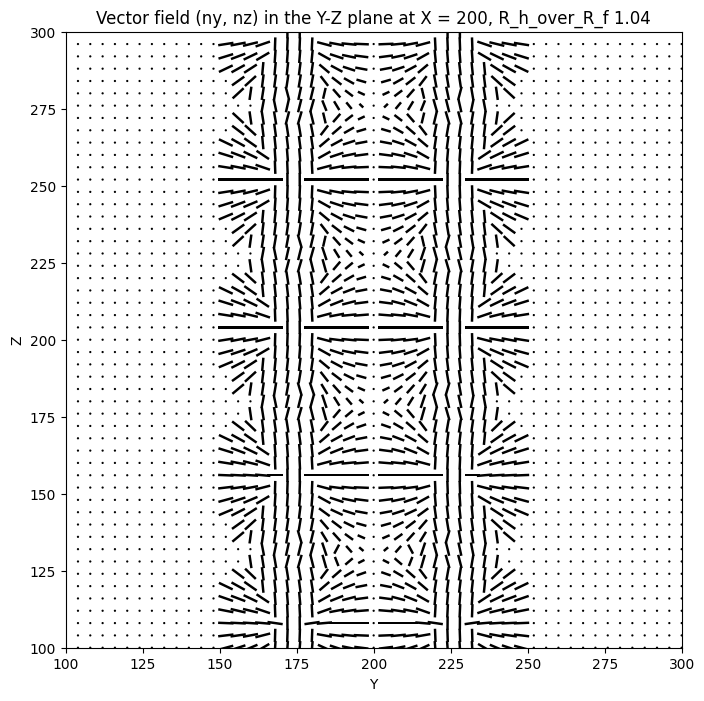

In [11]:
scale = 40
width = .004
headaxislength = 0
headlength = 0
headwidth = 1

k = 4

# Define thex-plane for display
x_display = int(Lx/2)  # You can set this to any value between 0 and Lx-1

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 8))

# Create a quiver plot for nx, nz in the X-Z plane at the specified X value
ax.quiver(Y[x_display, ::k, ::k], Z[x_display, ::k, ::k], ny[x_display, ::k, ::k], nz[x_display, ::k, ::k],
          pivot='middle', scale=scale, width=width, headaxislength=headaxislength, 
          headlength=headlength, headwidth=headwidth, linewidths=width)

# Add labels and title
ax.set_xlabel('Y')
ax.set_ylabel('Z')
ax.set_xlim([100, 300])  # Set the X-axis limits
ax.set_ylim([100, 300])  # Set the Y-axis limits
ax.set_title(f'Vector field (ny, nz) in the Y-Z plane at X = {x_display}, R_h_over_R_f {Rh_over_Rf}')
ax.set_aspect('equal')

#ax.set_xticks(np.arange(0, 11, 1))  # X ticks from 0 to 10
#ax.set_yticks(np.arange(0, 11, 1))  # Y ticks from 0 to 10

# Display the plot
#plt.grid()
plt.show()

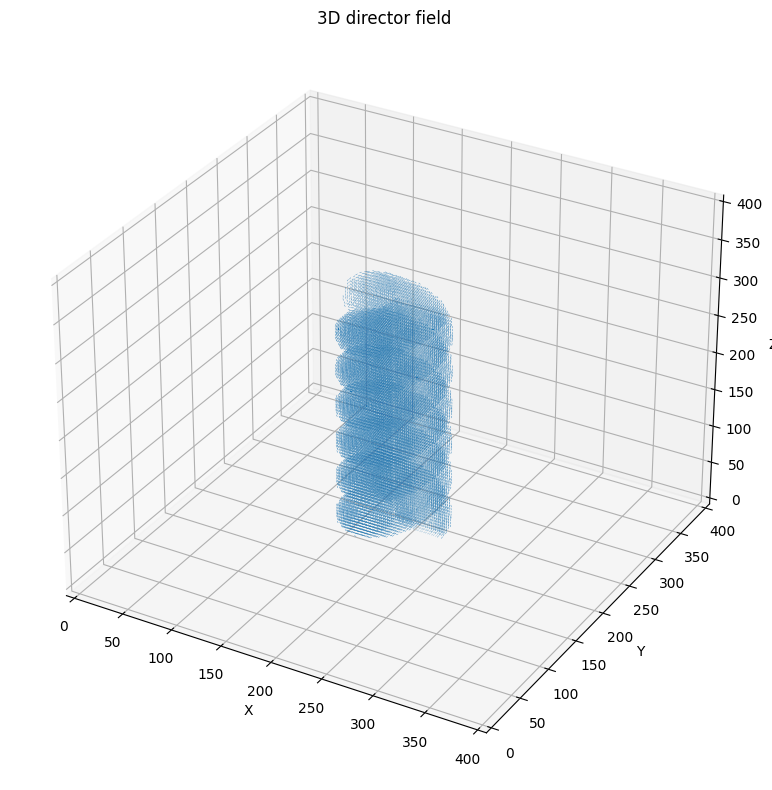

In [12]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
import matplotlib.pyplot as plt

scale = 4
k = 4  # same decimation factor

# Downsample the grid and director field
X_sub = X[::k, ::k, ::k]
Y_sub = Y[::k, ::k, ::k]
Z_sub = Z[::k, ::k, ::k]

nx_sub = nx[::k, ::k, ::k]
ny_sub = ny[::k, ::k, ::k]
nz_sub = nz[::k, ::k, ::k]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.quiver(
    X_sub, Y_sub, Z_sub,
    nx_sub, ny_sub, nz_sub,
    length=1.0/scale,  # like your "scale" in 2D
    normalize=True
)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D director field')

ax.set_xlim(0, Lx)
ax.set_ylim(0, Ly)
ax.set_zlim(0, Lz)
plt.tight_layout()
plt.show()

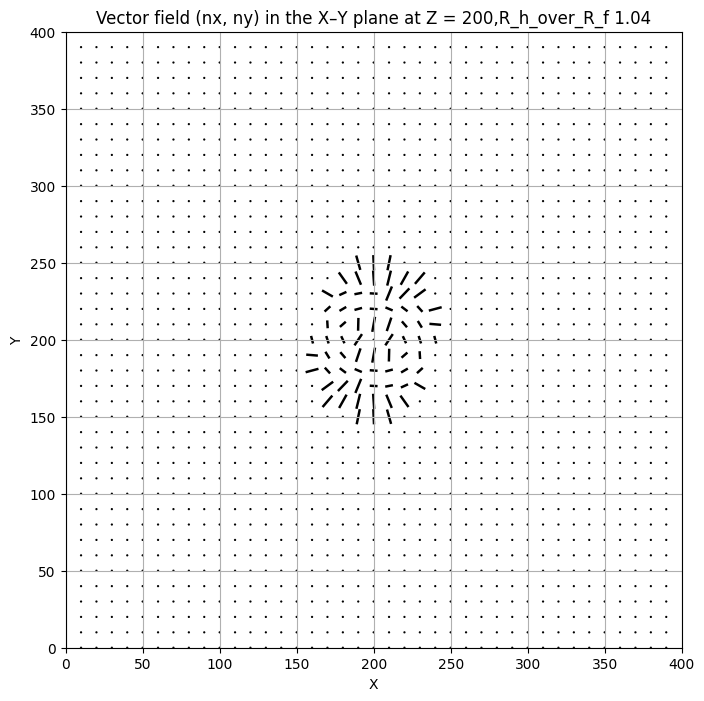

In [13]:
# Parameters
scale = 40
width = 0.004
headaxislength = 0
headlength = 0
headwidth = 1
k = 10

# Define the z-plane for display
z_display = 200  # any value between 0 and Lz-1

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Quiver plot for nx, ny in the X-Y plane at fixed Z
ax.quiver(
    X[::k, ::k, z_display],
    Y[::k, ::k, z_display],
    nx[::k, ::k, z_display],
    ny[::k, ::k, z_display],
    pivot='middle',
    scale=scale,
    width=width,
    headaxislength=headaxislength,
    headlength=headlength,
    headwidth=headwidth,
    linewidths=width
)

# Labels and formatting
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_xlim([0, 400])
ax.set_ylim([0, 400])
ax.set_title(f'Vector field (nx, ny) in the X–Y plane at Z = {z_display},R_h_over_R_f {Rh_over_Rf}')
ax.set_aspect('equal')

plt.grid()
plt.show()

In [14]:
from scipy.ndimage import affine_transform

def rotate_volume_and_vectors(nx, ny, nz, R):
    R_inv = np.linalg.inv(R)
    center = np.array(nx.shape) / 2

    def apply_rotation(data):
        return affine_transform(
            data,
            matrix=R_inv,
            offset=center - R_inv @ center,
            order=1,
            mode='nearest'
        )

    nx_r = apply_rotation(nx)
    ny_r = apply_rotation(ny)
    nz_r = apply_rotation(nz)

    directors = np.stack([nx_r, ny_r, nz_r], axis=-1)
    rotated = directors @ R.T

    return rotated

In [17]:
r_e_values = np.array([0.7]) * 1e-6  # filament diameters in meters
theta_values = [85,80,75,70,65,60,55,50,45]

L_str = Lx           
r_val = R_f
np_val = num_points

In [18]:
import os

output_dir = "lc-pom/Interpolated_Director_Field"
os.makedirs(output_dir, exist_ok=True)

for r_e in r_e_values:
    # Calculate the grid spacing factor based on r_e and r_s (assumed to be defined)
    res = r_e / R_f
    d_pom = round(res * 1e6, 6)  # grid spacing in micrometers
    #print(d_pom)

    # Set grid spacings (dx, dy, dz) for the simulation
    dx = dy = dz = d_pom

    for theta in theta_values:
        # Convert theta to radians for use in numpy trigonometric functions
        theta_rad = np.radians(theta)
        
        # Build the rotation matrix about the x-axis
        Rx = np.array([
            [1, 0, 0],
            [0, np.cos(theta_rad), -np.sin(theta_rad)],
            [0, np.sin(theta_rad),  np.cos(theta_rad)]
        ])
        
        # Rotate the director field using the provided function
        director_rot = rotate_volume_and_vectors(nx, ny, nz, Rx)
        nx_rot = director_rot[..., 0]
        ny_rot = director_rot[..., 1]
        nz_rot = director_rot[..., 2]
        
        # Stack the director field data along with the grid coordinates
        data = np.stack([
            X.ravel(), Y.ravel(), Z.ravel(),
            nx_rot.ravel(), ny_rot.ravel(), nz_rot.ravel()
        ], axis=1)
        
        # Create header lines for the file (customize if necessary)
        header1 = f"{Lx} {Ly} {Lz} {dx:.4f} {dy:.4f} {dz:.4f}"
        header2 = f"0 {Lx-1} 0 {Ly-1} 0 {Lz-1}"
        
        # Convert r_e to micrometers for the file name display
        re_um = r_e * 1e6
        
        re_str = f"{re_um:.1f}".replace('.', 'p')
        
        r_str = f"{r_val:.1f}".replace('.', 'p')

        o_str = f"{Omega_C:.3f}".replace('.', 'p')

        # Construct the output file name using the current theta and r_e values.
        # Example filename: rotated_90_helix_L_200_r_20_q_1p6_np_16000_re_2p5um.txt
        output_filename = (f"rotated_{theta}_double_helix_L_{L_str}_o_{o_str}_r_{r_str}_"f"np_{np_val}_re_{re_str}um.txt")
        output_path = os.path.join(output_dir, output_filename)
        
        # Write headers and data to the output file
        with open(output_path, 'w') as f:
            f.write(header1 + "\n")
            f.write(header2 + "\n")
            np.savetxt(f, data, fmt="%.6f")
        
        print(header1)
        print(output_filename)

400 400 400 0.0280 0.0280 0.0280
rotated_85_double_helix_L_400_o_0p170_r_25p0_np_3000_re_0p7um.txt
400 400 400 0.0280 0.0280 0.0280
rotated_80_double_helix_L_400_o_0p170_r_25p0_np_3000_re_0p7um.txt
400 400 400 0.0280 0.0280 0.0280
rotated_75_double_helix_L_400_o_0p170_r_25p0_np_3000_re_0p7um.txt
400 400 400 0.0280 0.0280 0.0280
rotated_70_double_helix_L_400_o_0p170_r_25p0_np_3000_re_0p7um.txt
400 400 400 0.0280 0.0280 0.0280
rotated_65_double_helix_L_400_o_0p170_r_25p0_np_3000_re_0p7um.txt
400 400 400 0.0280 0.0280 0.0280
rotated_60_double_helix_L_400_o_0p170_r_25p0_np_3000_re_0p7um.txt
400 400 400 0.0280 0.0280 0.0280
rotated_55_double_helix_L_400_o_0p170_r_25p0_np_3000_re_0p7um.txt
400 400 400 0.0280 0.0280 0.0280
rotated_50_double_helix_L_400_o_0p170_r_25p0_np_3000_re_0p7um.txt
400 400 400 0.0280 0.0280 0.0280
rotated_45_double_helix_L_400_o_0p170_r_25p0_np_3000_re_0p7um.txt
